Verifica se all'interno del dataset sono presenti per le colonne  "content" e "content_commit_sha" valori NaN oppure sono vuote e in caso affermativo, eliminare l'intera riga poichè non avere informazioni sul content non è plausibile. Eliminazione anche delle righe che hanno nella colonna "content" un testo troppo corto (es. meno di 10 parole).

In [1]:
from pathlib import Path
import pandas as pd

cwd = Path.cwd()
candidate_paths = [
    cwd / "dataset" / "dataset.csv",
    cwd.parent / "dataset" / "dataset.csv",
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("dataset.csv not found in ./dataset or ../dataset")

df = pd.read_csv(data_path)

required_cols = ["content", "content_commit_sha"]
mask_missing = df[required_cols].isna().any(axis=1)
mask_empty = df[required_cols].astype(str).apply(lambda col: col.str.strip().eq(""), axis=0)
mask_empty_any = mask_empty.any(axis=1)
df_clean = df[~(mask_missing | mask_empty_any)].copy()

word_counts = df_clean["content"].astype(str).str.split().str.len()
df_clean = df_clean[word_counts >= 10].copy()

print(f"Rows before: {len(df)}, after cleaning: {len(df_clean)}")

Rows before: 2303, after cleaning: 2179


Realizzazione del barplot per vedere la distribuzione della variabile commit_count

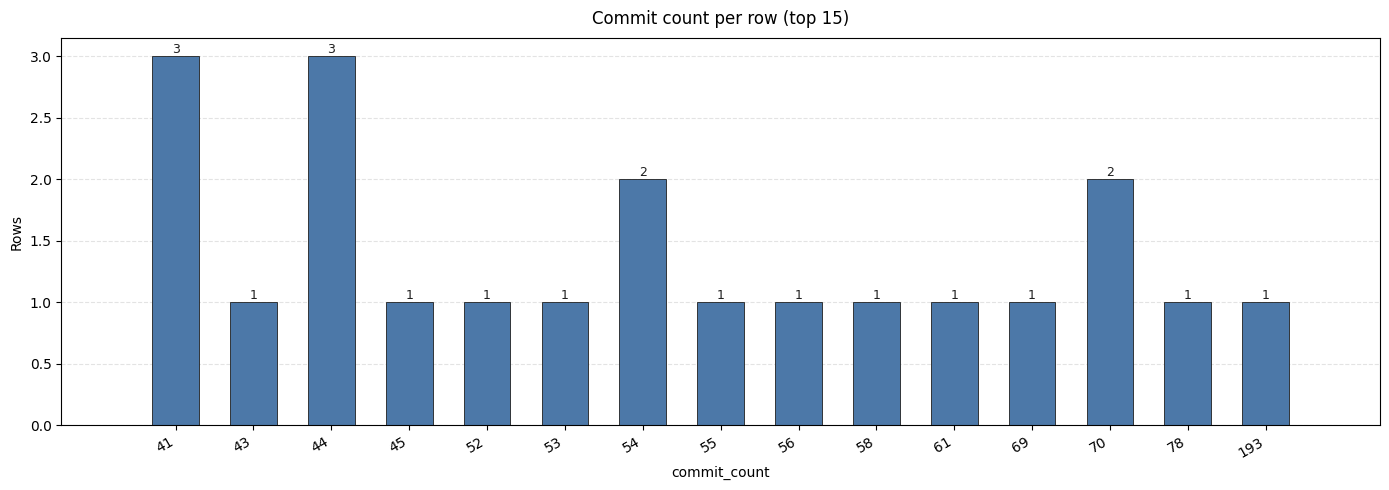

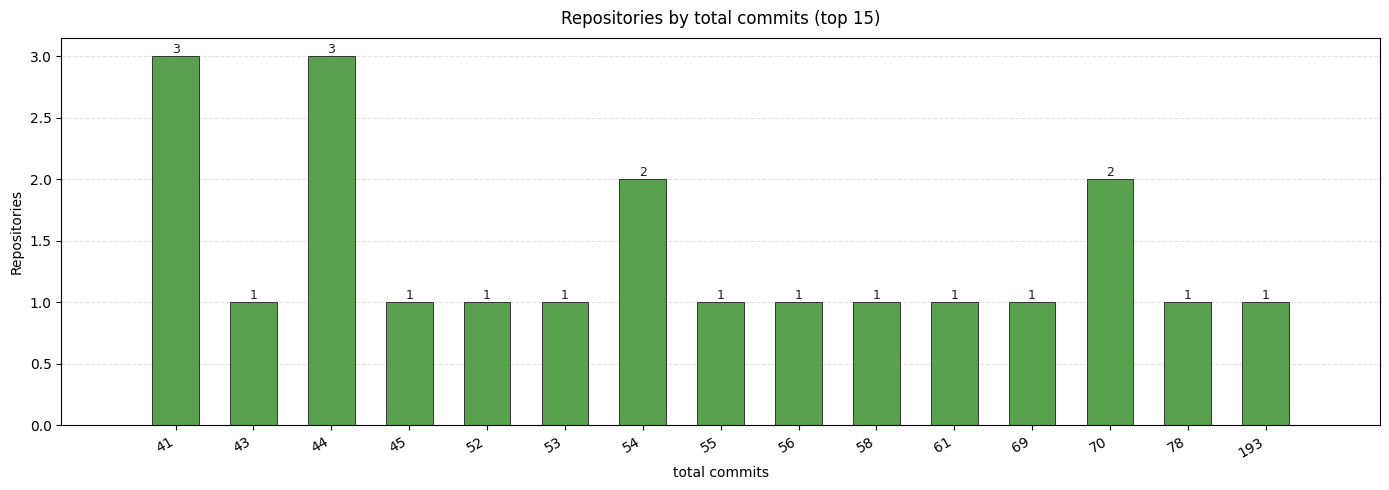

In [2]:
import matplotlib.pyplot as plt

TOP_N = 15  # show only the highest commit_count values

commit_count_num = pd.to_numeric(df_clean["commit_count"], errors="coerce")
row_counts = commit_count_num.dropna().astype(int).value_counts().sort_index()

if "repo_url" in df_clean.columns:
    repo_id = df_clean["repo_url"].astype(str)
else:
    repo_id = df_clean["repository_owner"].astype(str) + "/" + df_clean["repository_name"].astype(str)

repo_commit = (
    pd.DataFrame({"repo_id": repo_id, "commit_count": commit_count_num})
    .dropna(subset=["commit_count"])
    .groupby("repo_id")["commit_count"]
    .max()
 )
repo_counts = repo_commit.astype(int).value_counts().sort_index()

def top_by_commit(series, top_n):
    if series.empty or top_n is None or top_n <= 0:
        return series
    return series.iloc[-top_n:]

def barplot_counts(series, title, xlabel, ylabel, color):
    fig, ax = plt.subplots(figsize=(14, 5))
    x_labels = series.index.astype(int).astype(str)
    y = series.values
    positions = range(len(x_labels))
    bars = ax.bar(positions, y, color=color, edgecolor="#1f1f1f", linewidth=0.6, width=0.6)
    for rect, value in zip(bars, y):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height(),
            str(value),
            ha="center",
            va="bottom",
            fontsize=9,
            color="#1f1f1f",
            clip_on=True,
        )
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_xticks(list(positions))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.margins(x=0.08)
    plt.tight_layout()

barplot_counts(
    top_by_commit(row_counts, TOP_N),
    f"Commit count per row (top {TOP_N})",
    "commit_count",
    "Rows",
    "#4c78a8",
)
barplot_counts(
    top_by_commit(repo_counts, TOP_N),
    f"Repositories by total commits (top {TOP_N})",
    "total commits",
    "Repositories",
    "#59a14f",
)

Nel dataset sono state eliminate tutte quelle repository che presentano un numero di commit effettuati minore di 4

In [3]:
commit_count_num = pd.to_numeric(df_clean["commit_count"], errors="coerce")
df_commit40 = df_clean[commit_count_num >= 40].copy()

print(f"Rows with commit_count >= 40: {len(df_commit40)}")

Rows with commit_count >= 40: 22


Verifico se le colonne file_path e filename sono vuote

In [4]:
cols = ["file_path", "filename"]
missing_cols = [col for col in cols if col not in df_commit40.columns]

if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
    total_rows = len(df_commit40)
    if total_rows == 0:
        print("No rows to check.")
    else:
        def is_empty(series):
            return series.isna() | series.astype(str).str.strip().eq("")

        empty_flags = df_commit40[cols].apply(is_empty)
        for col in cols:
            empty_count = int(empty_flags[col].sum())
            print(f"{col}: empty {empty_count}/{total_rows} (all empty: {bool(empty_flags[col].all())})")

        both_empty = empty_flags.all(axis=1)
        print(f"Rows with both empty: {int(both_empty.sum())}/{total_rows}")
        print(f"All rows have both empty: {bool(both_empty.all())}")

file_path: empty 0/22 (all empty: False)
filename: empty 0/22 (all empty: False)
Rows with both empty: 0/22
All rows have both empty: False


Salvataggio delle modifiche effettuate in un nuovo dataset

In [5]:
from pathlib import Path

output_path = Path(data_path).parent / "dataset_cleaned.csv"
df_commit40.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: d:\Progetti\ContextWare\data-manipulation\dataset\dataset_cleaned.csv


Analisi del numero di commit totali effettuati sul context file (CLAUDE.md / AGENTS.md) per ogni repository, ricavato dal file `git_history_diffs.jsonl`.

Repository totali: 21
Repository                                              Commit sul context file
-------------------------------------------------------------------------------
MontrealAI/AGI-Alpha-Agent-v0                                              192
lbds137/tzurot                                                             157
VRSEN/agency-swarm                                                         153
CIRISAI/CIRISAgent                                                          86
steipete/Peekaboo                                                           78
zoedolan/Vybn                                                               75
devill/refakts                                                              69
UMEP-dev/SUEWS                                                              64
evmts/guillotine                                                            60
ryoppippi/ccusage                                                           58
kesslerio/attio-mcp-server  

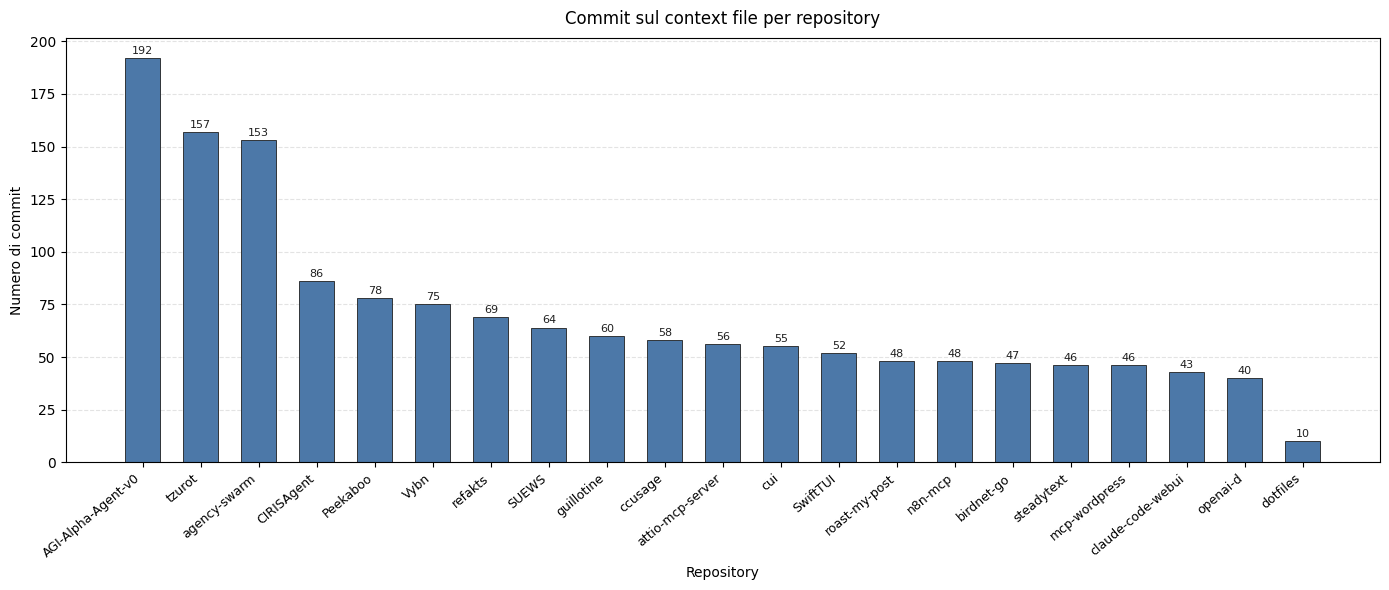

In [6]:
import json
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

jsonl_path = Path(os.getcwd()).parent.parent / "outputs" / "git_history_diffs.jsonl"
if not jsonl_path.exists():
    raise FileNotFoundError(f"File non trovato: {jsonl_path}")

commit_counts = defaultdict(int)
with open(jsonl_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        if "error" not in rec:
            repo = rec["repository_owner"] + "/" + rec["repository_name"]
            commit_counts[repo] += 1

repos = sorted(commit_counts.keys(), key=lambda r: commit_counts[r], reverse=True)
counts = [commit_counts[r] for r in repos]

print(f"Repository totali: {len(repos)}")
print(f"{'Repository':<55} {'Commit sul context file':>22}")
print("-" * 79)
for repo, count in zip(repos, counts):
    print(f"{repo:<55} {count:>22}")

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(repos)), counts, color="#4c78a8", edgecolor="#1f1f1f", linewidth=0.6, width=0.6)
for rect, value in zip(bars, counts):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1,
        str(value),
        ha="center", va="bottom", fontsize=8, color="#1f1f1f",
    )
ax.set_title("Commit sul context file per repository", pad=10)
ax.set_xlabel("Repository")
ax.set_ylabel("Numero di commit")
ax.set_xticks(range(len(repos)))
ax.set_xticklabels([r.split("/")[1] for r in repos], rotation=40, ha="right", fontsize=9)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

### Distribuzione dei diff per repository — Histogram e CDF

Visualizzazione della distribuzione del numero di commit sul context file per scegliere in modo informato la soglia di filtraggio.

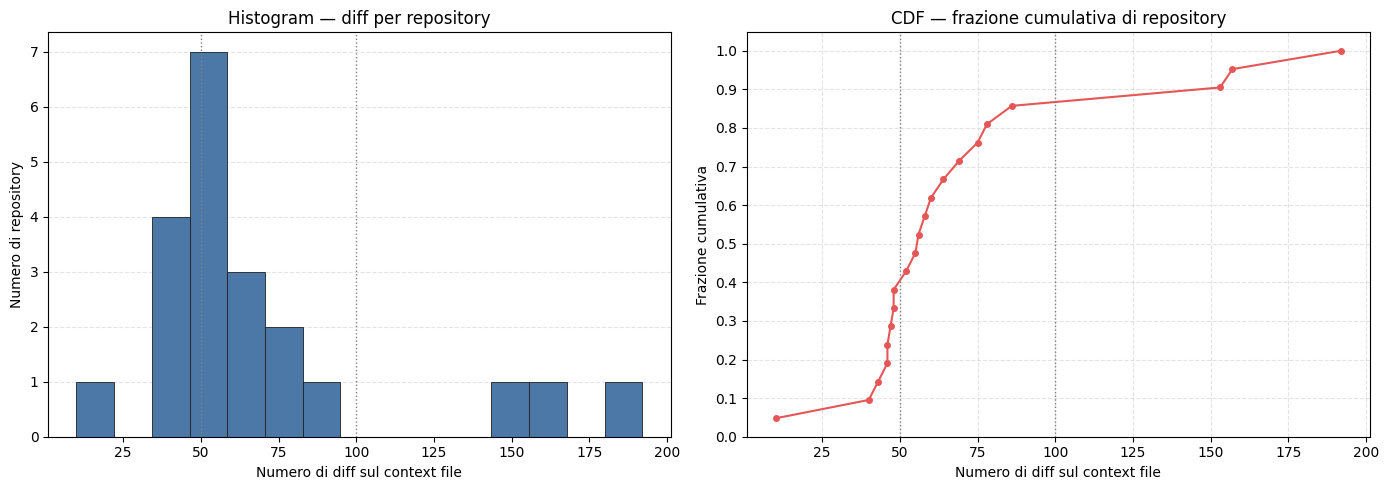


Statistiche:
  min:    10
  median: 56
  mean:   70.6
  max:    192
  repo con diff >=  30: 20/21
  repo con diff >=  50: 13/21
  repo con diff >=  75: 6/21
  repo con diff >= 100: 3/21


In [11]:
import numpy as np

values = sorted(commit_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(values, bins=15, color="#4c78a8", edgecolor="#1f1f1f", linewidth=0.6)
axes[0].set_title("Histogram — diff per repository")
axes[0].set_xlabel("Numero di diff sul context file")
axes[0].set_ylabel("Numero di repository")
axes[0].set_axisbelow(True)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)

# CDF
sorted_vals = np.sort(values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, marker="o", color="#e45756", linewidth=1.5, markersize=4)
axes[1].set_title("CDF — frazione cumulativa di repository")
axes[1].set_xlabel("Numero di diff sul context file")
axes[1].set_ylabel("Frazione cumulativa")
axes[1].set_yticks(np.arange(0, 1.1, 0.1))
axes[1].set_axisbelow(True)
axes[1].grid(linestyle="--", alpha=0.35)

for ax in axes:
    for v in [50, 100]:
        ax.axvline(v, color="gray", linestyle=":", linewidth=1, label=f"soglia={v}")

plt.tight_layout()
plt.show()

print(f"\nStatistiche:")
print(f"  min:    {min(values)}")
print(f"  median: {int(np.median(values))}")
print(f"  mean:   {np.mean(values):.1f}")
print(f"  max:    {max(values)}")
for soglia in [30, 50, 75, 100]:
    n = sum(1 for v in values if v >= soglia)
    print(f"  repo con diff >= {soglia:>3}: {n}/{len(values)}")

### Filtraggio del dataset in base alla soglia scelta

Vengono mantenute solo le repository che presentano un numero di diff sul context file maggiore o uguale alla soglia definita.

In [10]:
import pandas as pd
from pathlib import Path
import os

SOGLIA = 75  # modifica questo valore in base alla CDF

repos_valide = {repo for repo, count in commit_counts.items() if count >= SOGLIA}
print(f"Soglia: {SOGLIA} diff")
print(f"Repository che superano la soglia: {len(repos_valide)}/{len(commit_counts)}")
print()
for repo in sorted(repos_valide, key=lambda r: commit_counts[r], reverse=True):
    print(f"  {repo:<50} {commit_counts[repo]:>5} diff")

cleaned_path = Path(os.getcwd()).parent / "dataset" / "dataset_cleaned.csv"
df_cleaned = pd.read_csv(cleaned_path)
df_cleaned["_repo_key"] = df_cleaned["repository_owner"] + "/" + df_cleaned["repository_name"]
df_filtered = df_cleaned[df_cleaned["_repo_key"].isin(repos_valide)].drop(columns=["_repo_key"]).copy()

print(f"\nRighe nel dataset prima del filtro: {len(df_cleaned)}")
print(f"Righe nel dataset dopo il filtro:  {len(df_filtered)}")

Soglia: 75 diff
Repository che superano la soglia: 6/21

  MontrealAI/AGI-Alpha-Agent-v0                        192 diff
  lbds137/tzurot                                       157 diff
  VRSEN/agency-swarm                                   153 diff
  CIRISAI/CIRISAgent                                    86 diff
  steipete/Peekaboo                                     78 diff
  zoedolan/Vybn                                         75 diff

Righe nel dataset prima del filtro: 22
Righe nel dataset dopo il filtro:  6
